In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Problem Definition**

This project focuses on building a machine learning system capable of identifying fraudulent financial transactions.

The problem is treated as a supervised binary classification task where transactions are classified as either:

- legitimate transaction
- fraudulent transaction

The target variable for this project is:

`isFraud`

The main objective is not simply achieving high accuracy, but building a model capable of detecting fraudulent activity while maintaining a reasonable balance between fraud detection performance and false positive rates.

Because fraud cases are rare compared to legitimate transactions, accuracy alone is not sufficient for evaluating performance. The project will therefore focus more on metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC.

Recall will be especially important because missing fraudulent transactions can lead to financial losses. However, excessive false positives can also negatively affect customer experience and operational efficiency.

To address this tradeoff, the project will later include threshold optimization and explainability analysis using SHAP.

In [3]:
# import data handling
import pandas as pd
import numpy as np

# import data visualizaton
import matplotlib.pyplot as plt
import seaborn as sns

## **Dataset Overview**

This project uses the PaySim Mobile Money Fraud Detection dataset, which contains simulated financial transaction records designed to reflect mobile money transfer behavior.

The dataset includes transaction information such as:
- transaction type
- transfer amount
- sender and receiver balances
- account identifiers
- fraud labels

The target variable for this project is:

`isFraud`

This phase focuses on understanding the dataset structure, feature composition, and fraud distribution before moving into deeper data quality assessment and exploratory analysis.

In [4]:
# loading dataset
df = pd.read_csv('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/raw/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
# inspecting data shape
df.shape

(6362620, 11)

In [6]:
# checking dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
# investigate fruad distribution
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [8]:
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


### Fraud Distribution

The target variable is highly imbalanced, with fraudulent transactions representing only a very small fraction of the dataset.

This imbalance creates a major modeling challenge because a model can achieve very high accuracy while still failing to detect fraudulent activity effectively.

Because of this, evaluation metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC will be more important than accuracy alone.

In [9]:
# check memory usage
df.memory_usage(deep=True)

,0
Index,132
step,50900960
type,358994265
amount,50900960
nameOrig,378463420
oldbalanceOrg,50900960
newbalanceOrig,50900960
nameDest,378459785
oldbalanceDest,50900960
newbalanceDest,50900960


In [10]:
# check the memory usage in MB
df.memory_usage(deep=True).sum() / 1024**2

np.float64(1452.5654621124268)

In [11]:
# manage memory

df["step"] = df["step"].astype("int32")

df["type"] = df["type"].astype("category")

df["nameOrig"] = df["nameOrig"].astype("category")
df["nameDest"] = df["nameDest"].astype("category")

df["amount"] = df["amount"].astype("float32")

df["oldbalanceOrg"] = df["oldbalanceOrg"].astype("float32")
df["newbalanceOrig"] = df["newbalanceOrig"].astype("float32")

df["oldbalanceDest"] = df["oldbalanceDest"].astype("float32")
df["newbalanceDest"] = df["newbalanceDest"].astype("float32")

df["isFraud"] = df["isFraud"].astype("int8")
df["isFlaggedFraud"] = df["isFlaggedFraud"].astype("int8")

In [12]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(920.7109813690186)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        category
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        category
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(3), float32(5), int32(1), int8(2)
memory usage: 475.1 MB


### Memory Optimization

The dataset initially consumed a large amount of memory due to high-cardinality object columns and default numeric data types.

To improve memory efficiency before deeper analysis, several columns were converted to more appropriate data types such as:
- `float32`
- `int8`
- `category`

This significantly reduced overall memory usage and improved scalability for subsequent analysis and modeling.

In [14]:
# check for null values
df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [15]:
# check for duplicated entries
df.duplicated().sum()

np.int64(0)

In [16]:
insufficient_bal = df[df['oldbalanceOrg'] < df['amount']]
insufficient_bal.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
8,1,PAYMENT,4024.360107,C1265012928,2671.0,0.0,M1176932104,0.0,0.000000,0,0
10,1,DEBIT,9644.940430,C1900366749,4465.0,0.0,C997608398,10845.0,157982.125000,0,0
13,1,PAYMENT,11633.759766,C1716932897,10127.0,0.0,M801569151,0.0,0.000000,0,0
15,1,CASH_OUT,229133.937500,C905080434,15325.0,0.0,C476402209,5083.0,51513.441406,0,0
16,1,PAYMENT,1563.819946,C761750706,450.0,0.0,M1731217984,0.0,0.000000,0,0


In [17]:
insufficient_bal.shape

(4079080, 11)

In [18]:
# check specific transaction type for insufficient_bal
insufficient_bal['type'].value_counts().sort_values(ascending=False)
#

,count
type,
CASH_OUT,1981122
PAYMENT,1101124
TRANSFER,507512
CASH_IN,477536
DEBIT,11786


In [19]:
insufficient_bal[insufficient_bal['type'] == 'CASH_OUT']

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
15,1,CASH_OUT,229133.937500,C905080434,15325.000000,0.0,C476402209,5.083000e+03,5.151344e+04,0,0
42,1,CASH_OUT,110414.710938,C768216420,26845.410156,0.0,C1509514333,2.888000e+05,2.415160e+03,0,0
47,1,CASH_OUT,56953.898438,C1570470538,1942.020020,0.0,C824009085,7.025300e+04,6.410618e+04,0,0
48,1,CASH_OUT,5346.890137,C512549200,0.000000,0.0,C248609774,6.526370e+05,6.453431e+06,0,0
51,1,CASH_OUT,23261.300781,C2072313080,20411.529297,0.0,C2001112025,2.574200e+04,0.000000e+00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362306,718,CASH_OUT,169291.343750,C1569237054,26919.000000,0.0,C342077848,2.684602e+06,2.853894e+06,0,0
6362313,718,CASH_OUT,111963.718750,C1438119383,4514.000000,0.0,C99772923,1.549253e+05,2.668890e+05,0,0
6362317,718,CASH_OUT,317177.468750,C857156502,170.000000,0.0,C784108220,3.450421e+05,6.622196e+05,0,0
6362320,718,CASH_OUT,159188.218750,C691808084,3859.000000,0.0,C1818183087,0.000000e+00,1.591882e+05,0,0


In [20]:
insufficient_bal[insufficient_bal["nameDest"].astype(str).str.startswith("M")]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
8,1,PAYMENT,4024.360107,C1265012928,2671.000000,0.0,M1176932104,0.0,0.0,0,0
13,1,PAYMENT,11633.759766,C1716932897,10127.000000,0.0,M801569151,0.0,0.0,0,0
16,1,PAYMENT,1563.819946,C761750706,450.000000,0.0,M1731217984,0.0,0.0,0,0
25,1,PAYMENT,6061.129883,C1043358826,443.000000,0.0,M1558079303,0.0,0.0,0,0
28,1,PAYMENT,8901.990234,C1632497828,2958.909912,0.0,M33419717,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362299,718,PAYMENT,11317.419922,C1526212626,7155.000000,0.0,M1418729275,0.0,0.0,0,0
6362310,718,PAYMENT,6416.500000,C1532874529,360.000000,0.0,M265333537,0.0,0.0,0,0
6362311,718,PAYMENT,4276.609863,C590780626,155.000000,0.0,M2101529217,0.0,0.0,0,0
6362314,718,PAYMENT,17841.230469,C1045048098,10182.000000,0.0,M1878955882,0.0,0.0,0,0


In [21]:
# Does fraud occur equally across all transaction types
df.groupby('type')['isFraud'].value_counts().sort_values(ascending=False)
#

/tmp/ipykernel_2104/581449486.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('type')['isFraud'].value_counts().sort_values(ascending=False)


,,count
type,isFraud,
CASH_OUT,0,2233384
PAYMENT,0,2151495
CASH_IN,0,1399284
TRANSFER,0,528812
DEBIT,0,41432
CASH_OUT,1,4116
TRANSFER,1,4097
CASH_IN,1,0
DEBIT,1,0


In [22]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [23]:
pd.crosstab(df['isFlaggedFraud'], df['isFraud'])
#

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [24]:
# check for balance deicrepancy
sender_bal_err = (df['oldbalanceOrg'] - df['amount'] ) - df['newbalanceOrig']
sender_bal_err.describe()
#

,0
count,6.362620e+06
mean,-2.010926e+05
std,6.001532e+05
min,-9.244552e+07
25%,-2.496411e+05
50%,-6.867725e+04
75%,-2.954197e+03
max,4.000000e+00


In [25]:
print((sender_bal_err == 0).sum())

982675


In [26]:
print((sender_bal_err != 0).sum())

5379945


In [27]:
# Are fraudulent transactions themselves more balance-inconsistent than legitimate ones?
fraud_transactions = df[df["isFraud"] == 1]

fraud_sender_error = (
    fraud_transactions["oldbalanceOrg"]
    - fraud_transactions["amount"]
) - fraud_transactions["newbalanceOrig"]

fraud_sender_error.describe()

,0
count,8.213000e+03
mean,-1.069233e+04
std,2.651445e+05
min,-1.000000e+07
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.000000e+00


## Data Quality Assessment

The dataset appears structurally clean with no missing values or duplicated records detected during the initial quality checks. This means there is no immediate need for imputation or duplicate handling before analysis.

A deeper investigation into transaction balances showed that many transactions do not follow strict balance consistency rules. In several cases, the sender balance, transaction amount, and resulting balance did not align mathematically as expected. At first this appeared suspicious, but further analysis showed that these inconsistencies are common throughout the dataset and are likely related to the simulation mechanics of the PaySim environment rather than fraud alone.

Another important observation was the behavioral difference between account types. Destination accounts starting with `M` frequently showed unchanged balances during `PAYMENT` transactions, suggesting that these may represent merchant or system accounts where balances are not fully tracked within the simulation.

Fraud activity was found almost entirely in `TRANSFER` and `CASH_OUT` transactions, which suggests that fraudulent behavior in the dataset mainly involves moving and extracting funds quickly.

The `isFlaggedFraud` feature was also investigated because it appeared potentially suspicious. While all flagged transactions were truly fraudulent, only a very small number of fraud cases were actually flagged. This suggests that the feature behaves more like a strict rule-based fraud signal than a broad fraud indicator and may require caution during modeling.

Overall, this phase helped clarify the structure and behavior of the dataset while also revealing some important simulation-specific limitations that should be considered later during modeling and interpretation.


## Univariate Analysis

This phase focuses on understanding the individual behavior and distribution of features within the dataset before exploring relationships between variables.

The analysis will examine:

* transaction activity distribution
* transaction amount behavior
* balance distributions
* temporal transaction patterns
* skewness and outliers

The goal is to better understand how different features behave independently and identify patterns, irregularities, or dominant behaviors that may become important during fraud analysis and modeling.


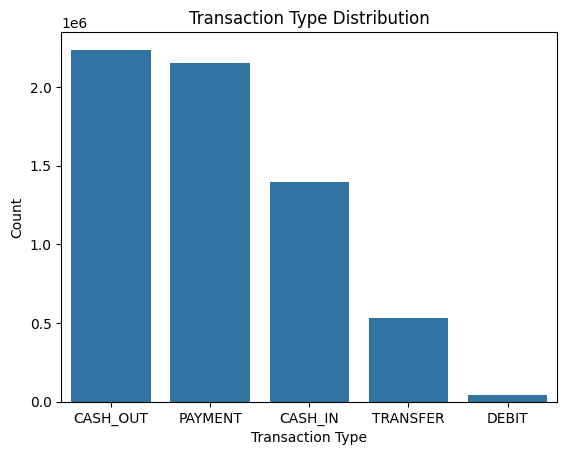

In [28]:
# transaction type distribution
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/transaction_type_distribution.png')
plt.show()

### Transaction Type Distribution

The distribution of transaction types shows that transaction activity is highly concentrated within a few categories. `CASH_OUT` and `PAYMENT` transactions account for the largest share of activity, followed by `CASH_IN`, while `DEBIT` transactions occur relatively infrequently.

This suggests that the mobile payment ecosystem represented in the dataset is primarily driven by a smaller set of transaction operations rather than evenly distributed transaction behavior across all categories.

The imbalance across transaction types may also become important later during modeling, particularly if certain transaction categories become strongly associated with fraud behavior or dominate feature importance.


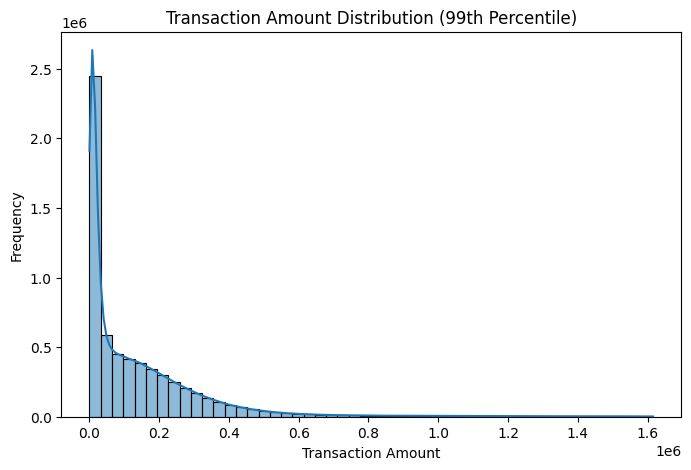

In [29]:
# Transaction Amount Distribution
upper_limit = df["amount"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(df[df["amount"] <= upper_limit]["amount"], kde=True, bins=50)

plt.title("Transaction Amount Distribution (99th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/transaction_amount_distribution.png')
plt.show()

### Transaction Amount Distribution

The transaction amount distribution is heavily right-skewed. Most transactions are concentrated around smaller transaction values, while only a few transactions involve very large amounts.

Even after clipping the distribution at the 99th percentile, the histogram still remains highly skewed, showing that the skewness is not caused only by a few extreme outliers.

The chart also suggests that lower-value transactions dominate the payment ecosystem, while large transactions occur much less frequently and form the long right tail of the distribution.

This kind of distribution may later create challenges during modeling since some algorithms can become sensitive to extreme transaction values and skewed feature distributions.


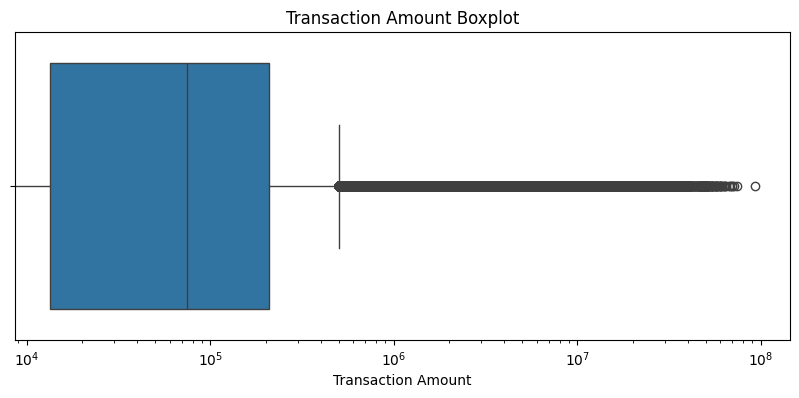

In [46]:
# boxplot for transaction amount
plt.figure(figsize=(10,4))
sns.boxplot(x=df["amount"])
plt.title("Transaction Amount Boxplot")
plt.xlabel("Transaction Amount")
plt.xscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/transaction_amount_boxplot.png')
plt.show()

### Transaction Amount Boxplot

The transaction amount boxplot confirms the presence of extreme outliers within the dataset. Most transaction amounts are concentrated within a relatively smaller range, while a large number of high-value transactions extend far beyond the upper whisker.

The strong concentration of points on the upper end of the distribution further supports the earlier observation that the `amount` feature is heavily right-skewed.

This suggests that while most transactions involve smaller amounts, a relatively small number of transactions contain exceptionally large values that may later influence model behavior and preprocessing decisions.


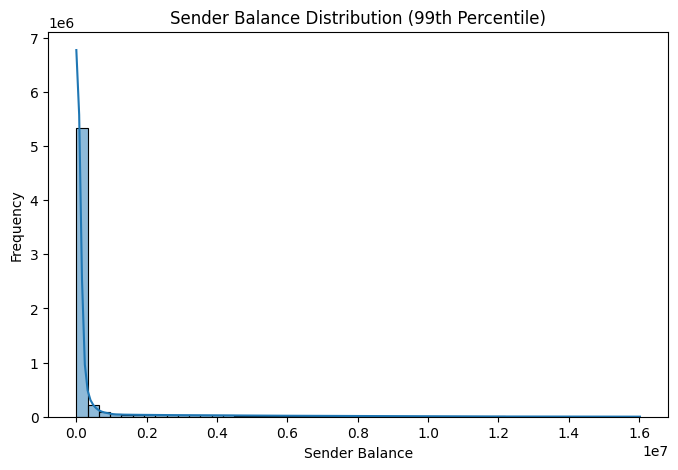

In [30]:
# Sender Balance Distribution (oldbalanceOrg)
upper_limit = df["oldbalanceOrg"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(df[df["oldbalanceOrg"] <= upper_limit]["oldbalanceOrg"], kde=True, bins=50)

plt.title("Sender Balance Distribution (99th Percentile)")
plt.xlabel("Sender Balance")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/sender_balance_distribution.png')
plt.show()
#

### Sender Balance Distribution

The sender balance distribution is highly skewed, with a large concentration of accounts having very low or zero balances. About one-third of transactions originate from accounts with a balance of zero, creating a strong spike near the lower end of the distribution.

The feature also contains some very large balance values, which stretch the distribution and make the histogram difficult to visualize clearly even after percentile clipping.

Overall, the distribution suggests that account balances within the dataset are not evenly distributed and are heavily concentrated around smaller balance values.


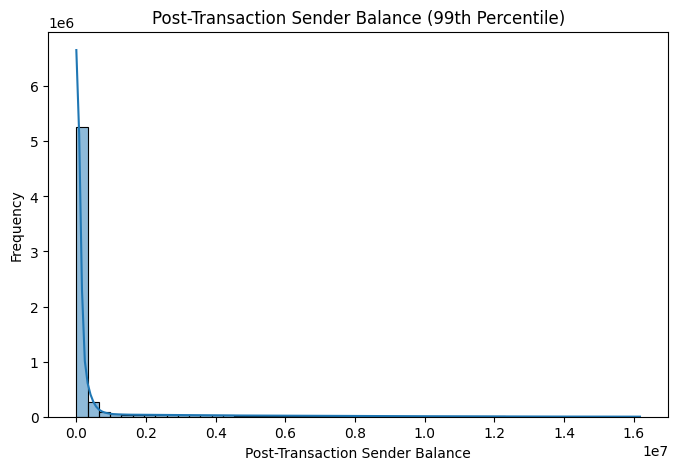

In [31]:
# Post-Transaction Sender Balance (newbalanceOrig)
upper_limit = df["newbalanceOrig"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(df[df["newbalanceOrig"] <= upper_limit]['newbalanceOrig'], bins=50, kde=True)

plt.title("Post-Transaction Sender Balance (99th Percentile)")
plt.xlabel("Post-Transaction Sender Balance")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/post_transaction_sender_balance.png')
plt.show()
#

### Post-Transaction Sender Balance Distribution

The post-transaction sender balance distribution is heavily right-skewed, with a very large concentration of balances close to zero. The sharp spike near the lower end of the distribution suggests that many transactions leave accounts with little or no remaining balance after the transaction is completed.

The distribution also contains a smaller number of very large balance values, which continue to stretch the distribution to the right even after percentile clipping.

Overall, the distribution looks very similar to the original sender balance distribution, suggesting that both balance-related features follow similar behavioral patterns within the dataset.


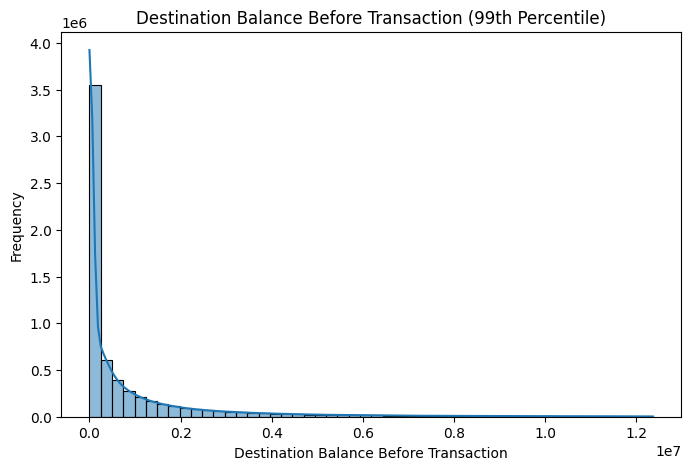

In [32]:
# Destination Balance Before Transaction (oldbalanceDest)
upper_limit = df["oldbalanceDest"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(df[df["oldbalanceDest"] <= upper_limit]["oldbalanceDest"], kde=True, bins=50)

plt.title("Destination Balance Before Transaction (99th Percentile)")
plt.xlabel("Destination Balance Before Transaction")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/destination_bal_old.png')
plt.show()

### Destination Balance Before Transaction Distribution

The destination balance distribution is also heavily right-skewed, with many accounts concentrated near lower balance values and fewer accounts holding very large balances.

However, compared to the sender balance distributions, destination balances appear more spread across higher balance ranges and less compressed around zero. This suggests that destination accounts may generally maintain larger balances than sender accounts within the transaction system.

The distribution still contains many zero-balance accounts, which is consistent with earlier observations involving merchant or system-related accounts within the dataset.


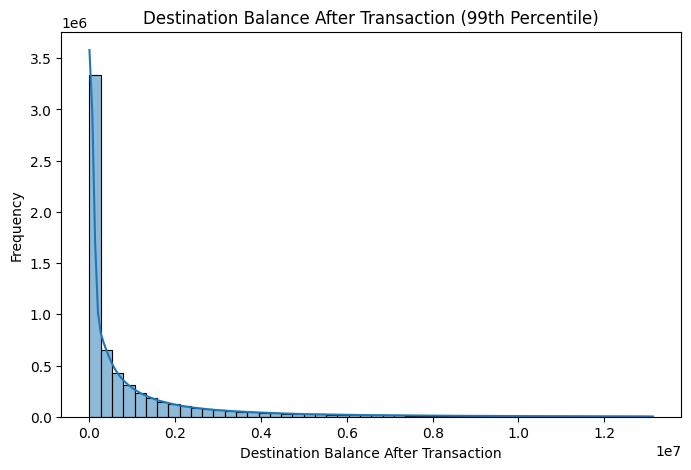

In [33]:
# Destination Balance After Transaction (newbalanceDest)
upper_limit = df["newbalanceDest"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(df[df["newbalanceDest"] <= upper_limit]["newbalanceDest"], kde=True, bins=50)
plt.title("Destination Balance After Transaction (99th Percentile)")
plt.xlabel("Destination Balance After Transaction")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/destination_bal_new.png')
plt.show()


### Destination Balance After Transaction Distribution

The destination balance after transaction distribution remains heavily right-skewed, with a large concentration of balances near the lower end of the distribution and fewer accounts holding very large balances.

The overall shape of the distribution looks very similar to the destination balance before transaction feature, suggesting that transactions do not drastically change the overall balance structure of destination accounts at the dataset level.

Compared to sender balance features, destination balances still appear more spread across higher balance ranges, which may suggest that destination accounts tend to retain or accumulate larger balances within the transaction system.


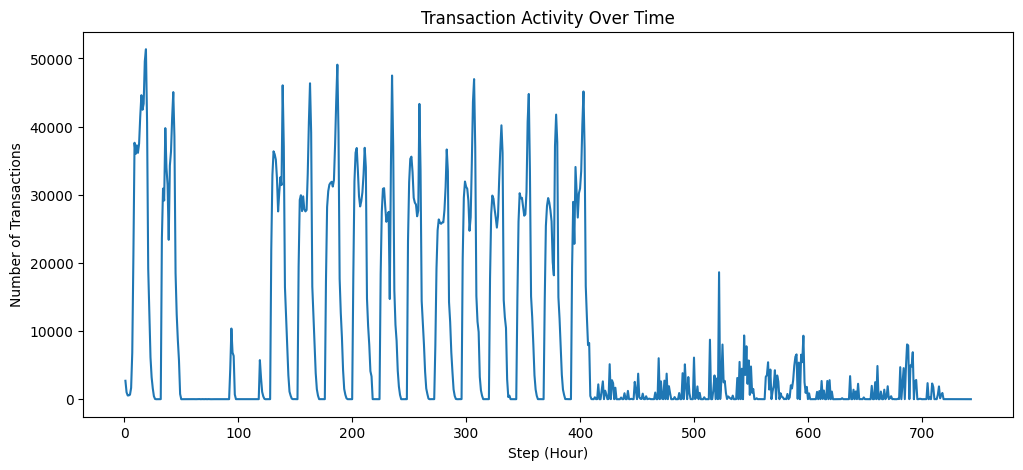

In [40]:
# Transaction Time Step (step)
# count transactions per step
step_counts = df["step"].value_counts().sort_index()

# plot transaction activity over time
plt.figure(figsize=(12,5))

sns.lineplot(
    x=step_counts.index,
    y=step_counts.values
)

plt.title("Transaction Activity Over Time")
plt.xlabel("Step (Hour)")
plt.ylabel("Number of Transactions")

plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/transaction_time_step.png')
plt.show()

### Transaction Activity Over Time

Transaction activity fluctuates heavily across time steps rather than remaining stable throughout the simulation period. The line plot shows repeated spike-and-drop patterns, suggesting cyclical transaction behavior within the payment system.

Several periods contain very sharp increases in transaction volume followed by rapid declines, creating a highly volatile activity pattern over time.

Another noticeable pattern is that transaction activity appears to decline significantly during later time steps compared to earlier parts of the simulation, indicating that transaction intensity is not evenly distributed across the entire simulated time period.


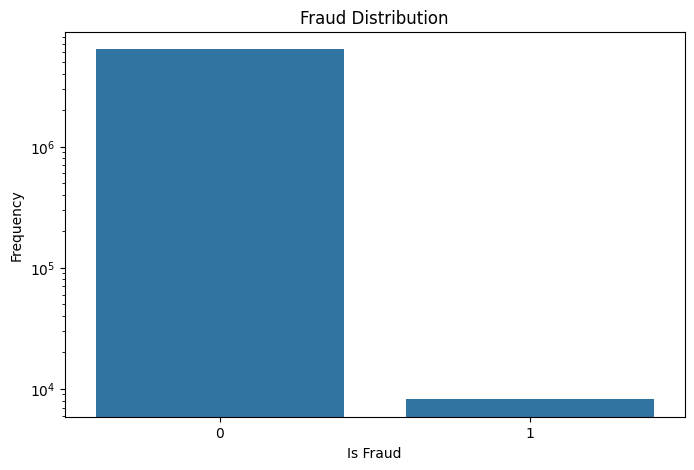

In [42]:
# Fraud Distribution (isFraud)
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='isFraud', order=df['isFraud'].value_counts().index)

plt.title("Fraud Distribution")
plt.xlabel("Is Fraud")
plt.ylabel("Frequency")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_distribution.png')
plt.show()

### Fraud Distribution

The target variable is extremely imbalanced, with legitimate transactions heavily dominating the dataset while fraudulent transactions represent only a very small fraction of total observations.

This imbalance is important because machine learning models may become biased toward predicting the majority class, especially if accuracy is used as the primary evaluation metric.

The distribution also highlights one of the major challenges in fraud detection systems: fraudulent transactions are rare but highly important to identify correctly.


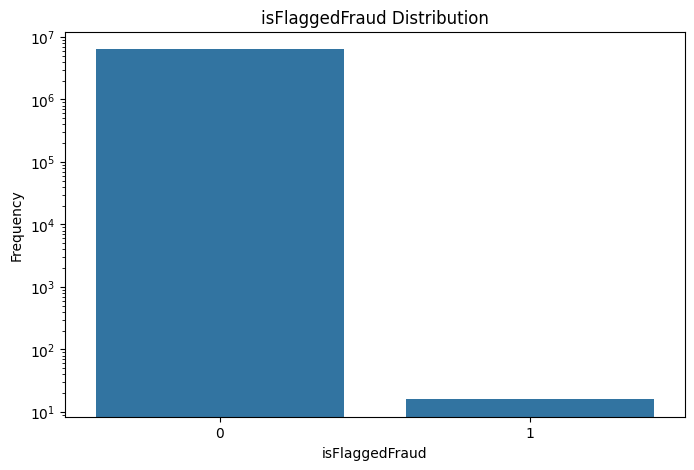

In [44]:
# isFlaggedFraud Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='isFlaggedFraud', order=df['isFlaggedFraud'].value_counts().index)

plt.title("isFlaggedFraud Distribution")
plt.xlabel("isFlaggedFraud")
plt.ylabel("Frequency")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/is_flagged_fraud.png')
plt.show()
#

### isFlaggedFraud Distribution

The `isFlaggedFraud` feature is extremely imbalanced, with only a very small number of transactions being flagged by the system.

This suggests that the built-in fraud flagging mechanism is highly selective and flags transactions very conservatively. Earlier analysis also showed that flagged transactions were almost always truly fraudulent, but the system failed to capture most fraud cases present in the dataset.

This behavior suggests that the feature acts more like a strict rule-based fraud signal rather than a broad fraud detection mechanism. Because of its strong relationship with the target variable, the feature may also introduce potential leakage concerns during modeling.


## **Bivariate & Multivariate Analysis**

This phase focuses on exploring the relationships between features and how they interact with fraudulent transaction behavior within the dataset.

The analysis will investigate:

* fraud distribution across transaction types
* fraud behavior across transaction amounts and balances
* temporal fraud activity
* feature interactions
* correlation patterns between variables

The goal is to identify behavioral differences between fraudulent and non-fraudulent transactions, uncover potential predictive patterns, and better understand how fraud operates within the simulated payment ecosystem.


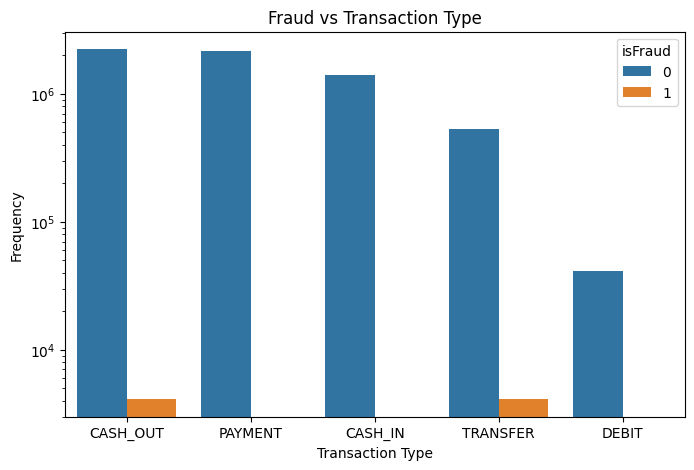

In [48]:
# Fraud vs Transaction Type
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='type', hue='isFraud', order=df['type'].value_counts().index)

plt.title("Fraud vs Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Frequency")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_vs_transaction_type.png')
plt.show()
#

### Fraud Distribution Across Transaction Types

Fraudulent transactions are not evenly distributed across transaction types within the dataset. Fraud activity appears only in `CASH_OUT` and `TRANSFER` transactions, while `PAYMENT`, `CASH_IN`, and `DEBIT` transactions show no fraudulent observations.

This suggests that fraudulent behavior is strongly associated with transaction types that directly move funds between accounts or remove funds from the system.

Another important observation is that although `TRANSFER` transactions occur less frequently overall compared to `CASH_OUT`, they still contain a large number of fraudulent transactions. This may indicate a higher fraud concentration within transfer-related activities.

Overall, transaction type appears to be a potentially important feature for fraud detection modeling.


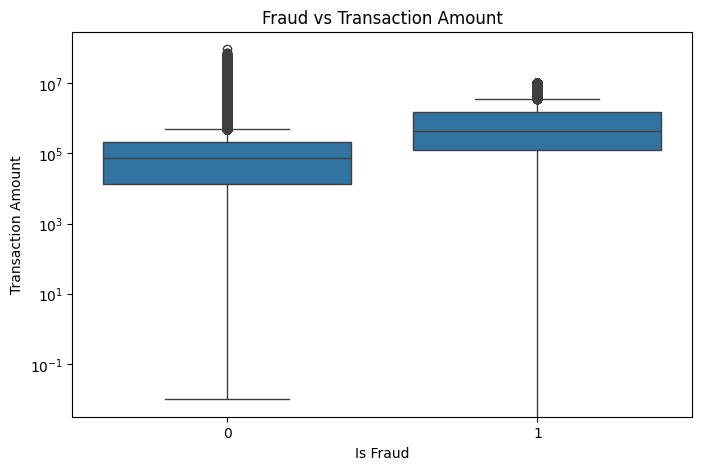

In [51]:
# Fraud vs Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(x=df['isFraud'], y=df['amount'])

plt.title("Fraud vs Transaction Amount")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_vs_transaction_amount.png')
plt.show()

### Fraud vs Transaction Amount

The transaction amount distributions for fraudulent and non-fraudulent transactions show noticeable differences. Fraudulent transactions generally have a higher median transaction amount compared to legitimate transactions, suggesting that fraud activity tends to involve larger financial values.

Non-fraudulent transactions appear more widely distributed and contain a larger number of extreme outliers, likely due to the much larger volume of legitimate transactions present in the dataset.

Although the distributions still overlap, transaction amount appears to provide meaningful separation between fraud and non-fraud behavior, making it a potentially useful feature for fraud detection modeling.


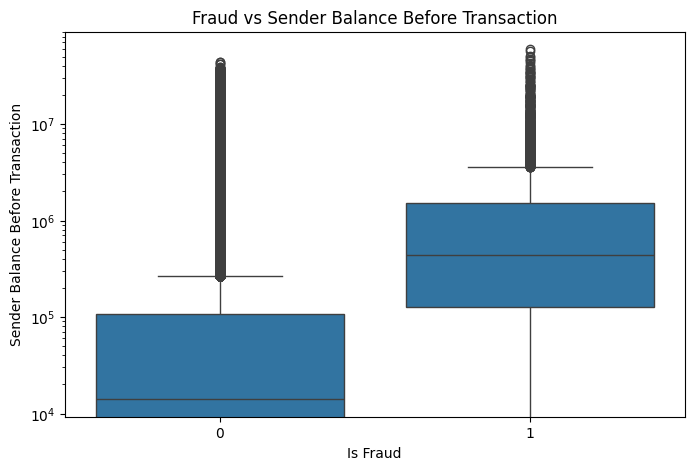

In [52]:
# Fraud vs Sender Balance Before Transaction (oldbalanceOrg)
plt.figure(figsize=(8,5))

sns.boxplot(x=df['isFraud'], y=df['oldbalanceOrg'])

plt.title("Fraud vs Sender Balance Before Transaction")
plt.xlabel("Is Fraud")
plt.ylabel("Sender Balance Before Transaction")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_vs_sender_balance_before.png')
plt.show()

### Fraud vs Sender Balance Before Transaction

The sender balance distributions for fraudulent and non-fraudulent transactions show clear differences. Fraudulent transactions generally originate from accounts with substantially higher balances compared to legitimate transactions, with the fraud distribution shifted noticeably toward larger balance ranges.

Non-fraudulent transactions are much more concentrated around lower balance values and contain a larger number of near-zero balance observations, while fraudulent transactions appear less associated with very low account balances.

The distributions also suggest that fraudulent activity tends to involve accounts capable of moving larger financial amounts, which aligns with earlier observations from the transaction amount analysis.

Overall, sender balance before transaction appears to contain strong discriminatory information for fraud detection modeling.


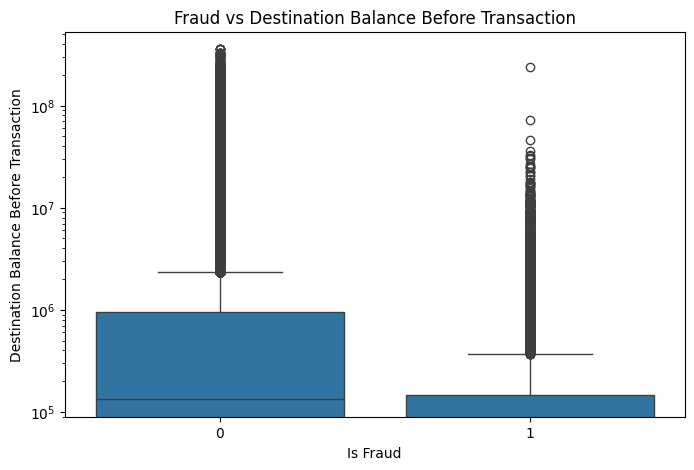

In [53]:
# Fraud vs Destination Balance Before Transaction (oldbalanceDest)
plt.figure(figsize=(8,5))

sns.boxplot(x=df['isFraud'], y=df['oldbalanceDest'])

plt.title("Fraud vs Destination Balance Before Transaction")
plt.xlabel("Is Fraud")
plt.ylabel("Destination Balance Before Transaction")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_vs_destination_balance_before.png')
plt.show()

### Fraud vs Destination Balance Before Transaction

The destination balance distributions show noticeable differences between fraudulent and non-fraudulent transactions. Fraud-related transactions generally involve destination accounts with lower balances compared to legitimate transactions, while non-fraudulent destination balances are more widely distributed and contain substantially larger balance values.

The fraud distribution also appears more concentrated within lower balance ranges, suggesting that fraudulent transactions may be directed toward a narrower group of destination account profiles.

Combined with earlier observations showing higher sender balances in fraudulent transactions, the pattern may suggest that fraud activity often involves moving funds from financially stronger accounts into comparatively lower-balance destination accounts.

Overall, destination balance before transaction appears to contain useful behavioral information for fraud detection analysis.


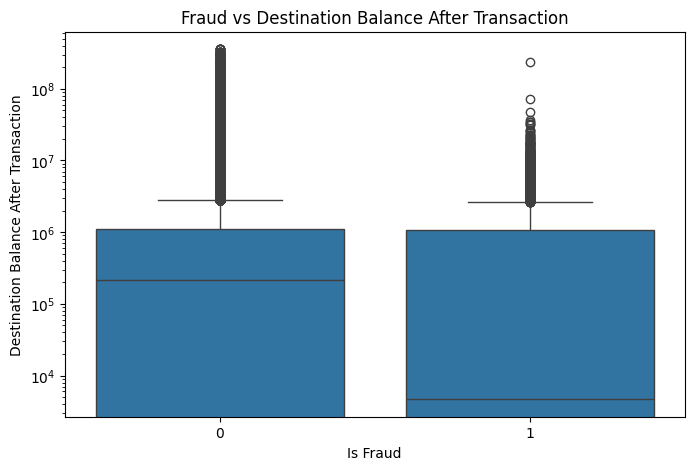

In [54]:
# Fraud vs Destination Balance After Transaction (newbalanceDest)
plt.figure(figsize=(8,5))

sns.boxplot(x=df['isFraud'], y=df['newbalanceDest'])

plt.title("Fraud vs Destination Balance After Transaction")
plt.xlabel("Is Fraud")
plt.ylabel("Destination Balance After Transaction")
plt.yscale('log')
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_vs_destination_balance_after.png')
plt.show()

### Fraud vs Destination Balance After Transaction

The destination balance after transaction distributions continue to show noticeable differences between fraudulent and non-fraudulent transactions. Non-fraudulent transactions generally maintain higher median destination balances, while fraud-related transactions remain concentrated around lower balance ranges even after the transaction is completed.

Although both classes contain extreme balance outliers, the fraud distribution appears more unevenly spread and less concentrated around higher balance values compared to legitimate transactions.

When combined with earlier balance analyses, the pattern suggests that fraudulent transactions often move funds from higher-balance sender accounts into destination accounts that still remain relatively low-balance after receiving the transaction.

Overall, destination balance after transaction continues to provide useful behavioral information for fraud detection analysis.


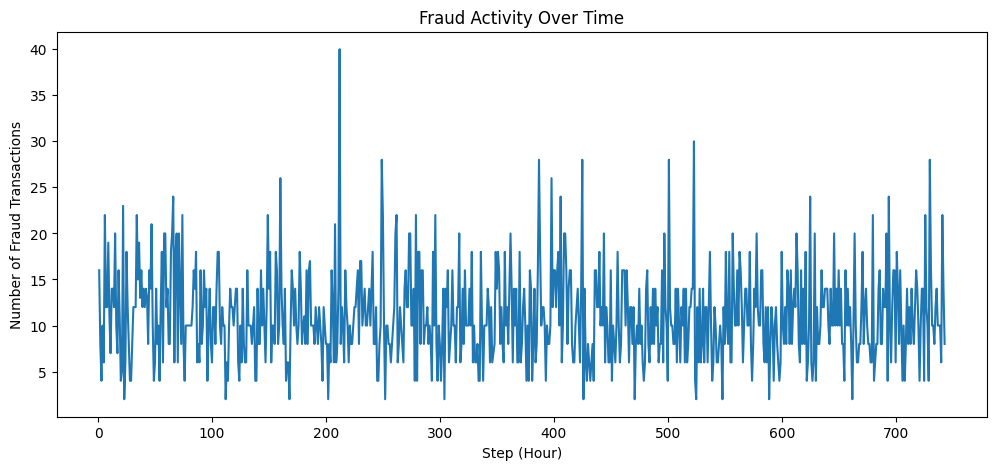

In [59]:
# filter only fraud transactions
fraud_df = df[df["isFraud"] == 1]

# count fraud transactions per step
fraud_step_counts = fraud_df["step"].value_counts().sort_index()

# plot fraud activity over time
plt.figure(figsize=(12,5))

sns.lineplot(
    x=fraud_step_counts.index,
    y=fraud_step_counts.values
)

plt.title("Fraud Activity Over Time")
plt.xlabel("Step (Hour)")
plt.ylabel("Number of Fraud Transactions")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_activity_over_time.png')
plt.show()

### Fraud Activity Over Time

Fraud activity fluctuates across the simulation timeline rather than remaining evenly distributed. The line plot shows multiple sudden spikes and drops in fraud frequency, indicating that fraudulent behavior occurs irregularly over time.

Unlike the earlier overall transaction activity pattern, fraud activity does not appear strongly cyclical and instead shows a more scattered and burst-like structure across different time periods.

Another important observation is that fraud transactions continue to occur throughout most parts of the simulation timeline, even though the number of fraud events per step remains relatively low overall. This further highlights the rarity of fraudulent activity within the payment ecosystem.


/tmp/ipykernel_2104/3524940831.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = df.groupby('type')['isFraud'].mean()


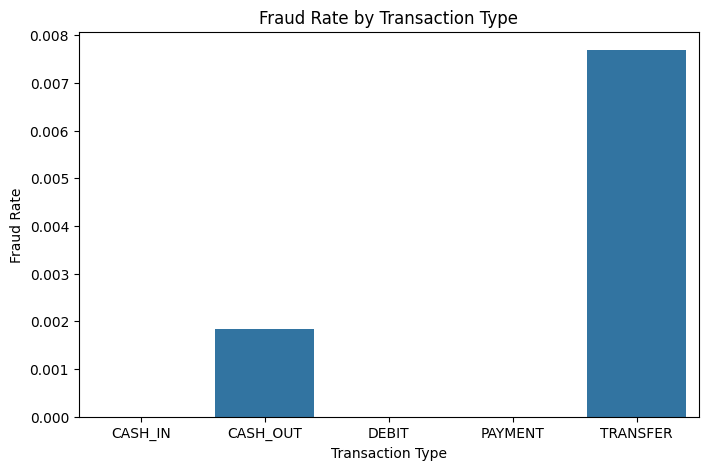

In [60]:
# Fraud Rate by Transaction Type
fraud_rate = df.groupby('type')['isFraud'].mean()

plt.figure(figsize=(8,5))

sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/fraud_rate_by_transaction_type.png')
plt.show()

### Fraud Rate by Transaction Type

The fraud rate analysis reveals that `TRANSFER` transactions have the highest fraud rate within the dataset, despite `CASH_OUT` transactions having larger overall fraud counts earlier in the analysis.

This highlights the importance of analyzing normalized fraud proportions rather than relying only on raw fraud frequencies, since transaction categories differ significantly in total transaction volume.

`PAYMENT`, `DEBIT`, and `CASH_IN` transactions show little to no fraud activity, while fraud remains heavily concentrated within `TRANSFER` and `CASH_OUT` transaction types.

The large difference in fraud rates across transaction categories also suggests that transaction type may become a highly informative feature for fraud detection modeling.


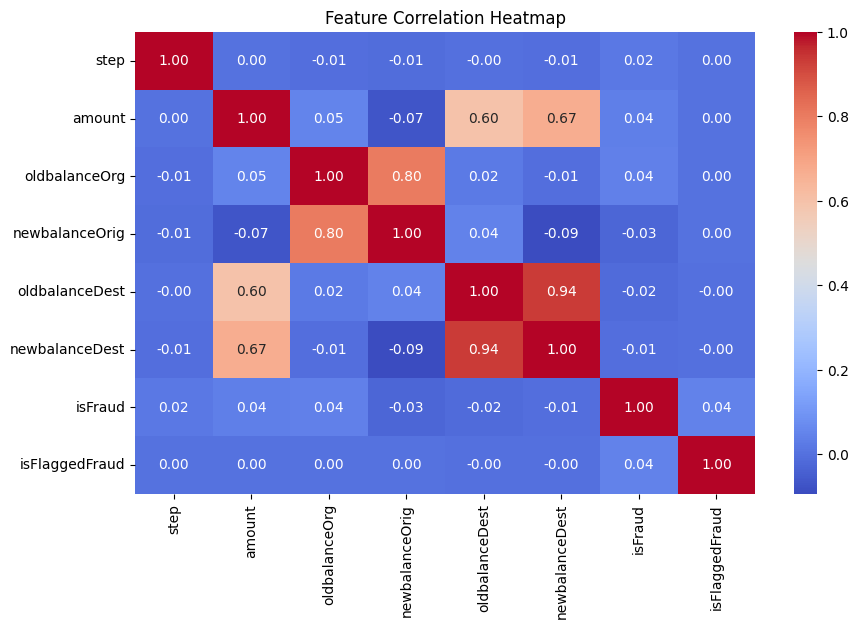

In [63]:
# select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# compute correlation matrix
corr_matrix = numeric_df.corr(method='spearman')

# plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix, annot=True,fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/feature_correlation_heatmap.png')
plt.show()

### Feature Correlation Heatmap

The correlation heatmap reveals strong relationships among several balance-related variables within the dataset. The strongest positive correlation exists between `oldbalanceDest` and `newbalanceDest`, followed by the relationship between `oldbalanceOrg` and `newbalanceOrig`. These strong correlations are expected because account balances before and after transactions are naturally connected.

Transaction amount also shows moderate positive relationships with destination account balances, suggesting that larger transactions tend to involve accounts holding larger balances.

Another important observation is that the direct correlations with `isFraud` remain relatively weak across individual features. This suggests that fraudulent behavior may not depend on simple linear relationships alone and may instead involve more complex interaction patterns between variables.

The heatmap also highlights potential redundancy among balance-related features, which may become important later during feature engineering and model development.


## EDA Conclusion

The exploratory analysis showed that fraudulent transactions in the dataset are not randomly distributed across the payment system. Fraud activity is mainly concentrated within `TRANSFER` and `CASH_OUT` transactions, with `TRANSFER` transactions having the highest fraud rate overall.

Fraudulent transactions also tend to involve larger transaction amounts and are more likely to originate from accounts with higher sender balances compared to legitimate transactions. In contrast, destination accounts involved in fraud generally maintain lower balances even after transactions are completed.

The analysis further showed that fraud activity occurs continuously throughout the simulation timeline, although the frequency fluctuates across different periods.

Another important finding is the severe class imbalance within the dataset, where fraudulent transactions represent only a very small portion of total transactions. This highlights the need for careful model evaluation and imbalance-aware machine learning techniques during the modeling phase.

Overall, the EDA suggests that fraudulent behavior in the dataset is influenced by a combination of transaction type, transaction amount, balance behavior, and temporal activity patterns rather than a single isolated feature.
